# Práctica 1 — Problema de Clique Máximo

**Autor:** Jordi Blasco Lozano


#### Índice

1. Resumen
2. Introducción
3. Carga de imports y conjuntos de datos
4. Tareas de implementación
   - 4.1 Utilidades generales
   - 4.2 Fuerza bruta (parte 0)
     - Tarea 0.1: `is_clique()`
     - Tarea 0.2: `brute_force_max_clique()`
     - Tarea 0.3: `test_brute_force()`
     - Tarea 0.4: evaluación sobre dataset
   - 4.3 Formulación de Motzkin-Straus (parte 1)
     - Tarea 1.1: funciones objetivo
     - Tarea 1.2: verificación del teorema
   - 4.4 Dinámicas replicadoras (parte 2)
     - Tarea 2.1: `replicator_dynamics()`
     - Tarea 2.2: `decode_clique()`
     - Tarea 2.3: visualización de convergencia
     - Tarea 2.4: evaluación sobre dataset
   - 4.5 GNN + Dinámicas replicadoras (parte 3)
     - Tarea 3.1: `compute_node_features()`
     - Tarea 3.2: `MaxCliqueGNN`
     - Tarea 3.3: RD diferenciable
     - Tarea 3.4: `maxclique_loss()`
     - Tarea 3.5: entrenamiento
     - Tarea 3.6: evaluación
   - 4.6 Presentación de resultados
5. Ejercicio 1
   - 5.1 Implementar `is_clique()` y `brute_force_max_clique()`
   - 5.2 Prueba en un grafo sintético pequeño
   - 5.3 Aplicación a los primeros 20 grafos de IMDB y contraste adicional con COLLAB
   - 5.4 Informe del ejercicio
6. Ejercicio 2
   - 6.1 Implementación de funciones objetivo
   - 6.2 Crear 3 grafos de test con máximas cliques conocidas
   - 6.3 Verificar que el teorema se cumple en cada caso
   - 6.4 Demostrar el problema de la solución espuria en el grafo cherry
   - 6.5 Demostrar que la regularización lo corrige
   - 6.6 Informe del ejercicio
7. Ejercicio 3
   - 7.1 Implementar RD con el decodificador
   - 7.2 Visualización de la convergencia en un grafo pequeño
   - 7.3 Aplicación de RD en IMDB y COLLAB
   - 7.4 Comparación con fuerza bruta en los grafos pequeños de IMDB
   - 7.5 Informe del ejercicio
8. Ejercicio 4
   - 8.1 Implementar el pipeline completo
   - 8.2 Entrenar en IMDB y evaluar en grafos hold-out
   - 8.3 Comparación de los tres enfoques
      - Fuerza Bruta
      - RD puro desde el baricentro
      - GNN + RD
   - 8.4 Ablación: variar el número de iteraciones de RD (train: 0,1,3,5; test: 10,50,100)
   - 8.5 Informe del ejercicio
9. Ejercicio 5
   - 9.1 Tabla resumen final
   - 9.2 Informe comparativo final
10. Conclusiones


## 1. Resumen



En esta práctica se ha abordado el problema de clique máximo desde tres niveles de complejidad. En primer lugar se ha implementado una referencia exacta por fuerza bruta, útil para fijar un ground truth en grafos pequeños. Después se ha trabajado con la relajación continua de Motzkin-Straus y con Replicator Dynamics como procedimiento de optimización sobre el simplex. Por último se ha añadido un modelo híbrido GNN + RD para estudiar si una inicialización aprendida puede mejorar el comportamiento de RD puro.

El notebook se ha reorganizado para que la sección de implementación quede separada de los ejercicios, pero respetando los apartados del enunciado.


## 2. Introducción



Una clique en un grafo no dirigido es un subconjunto de nodos en el que todos los pares posibles están conectados. La clique máxima es la de mayor tamaño, y encontrarla es un problema NP-hard. Esa dificultad explica por qué una estrategia exacta solo es útil en instancias pequeñas y por qué tiene sentido estudiar formulaciones relajadas y métodos iterativos.

En esta práctica se ha seguido la secuencia natural del enunciado. Primero se ha programado fuerza bruta como referencia exacta. Después se ha comprobado numéricamente el teorema de Motzkin-Straus y el papel de la regularización frente a soluciones espurias. A continuación se ha implementado Replicator Dynamics y se ha evaluado sobre IMDB y COLLAB. Finalmente se ha entrenado un modelo híbrido GNN + RD para comparar su comportamiento frente a RD puro y analizar una pequeña ablación sobre el número de iteraciones de refinamiento.


## 3. Carga de imports y conjuntos de datos



In [253]:
import random
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from torch_geometric.datasets import TUDataset
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

imdb_dataset = TUDataset(root=str(DATA_DIR), name="IMDB-BINARY")
collab_dataset = TUDataset(root=str(DATA_DIR), name="COLLAB")

print(f"Dispositivo de trabajo: {DEVICE}")
print(f"IMDB-BINARY: {len(imdb_dataset)} grafos")
print(f"COLLAB: {len(collab_dataset)} grafos")

sample_graph = imdb_dataset[0]
print("\nEjemplo de IMDB-BINARY:")
print(f"  Nodos: {sample_graph.num_nodes}")
print(f"  Aristas: {sample_graph.num_edges}")
print(f"  Etiqueta del grafo: {int(sample_graph.y.item()) if hasattr(sample_graph, 'y') else 'N/D'}")


Dispositivo de trabajo: cuda
IMDB-BINARY: 1000 grafos
COLLAB: 5000 grafos

Ejemplo de IMDB-BINARY:
  Nodos: 20
  Aristas: 146
  Etiqueta del grafo: 0


## 4. Tareas de implementación



En esta sección se han agrupado las funciones y clases reutilizables. 


#### 4.1 Utilidades generales



Aquí se han reunido funciones auxiliares de conversión, medida de tiempos, particionado y resumen de resultados. No pertenecen al enunciado como tareas específicas, pero permiten que los ejercicios posteriores queden más limpios.


In [254]:
def pyg_to_adjacency(data):
    """Convierte un grafo de PyG a matriz de adyacencia densa de tipo float."""
    G = to_networkx(data, to_undirected=True)
    A = nx.to_numpy_array(G, dtype=float)
    np.fill_diagonal(A, 0.0)
    return A


def clique_to_simplex(clique, n):
    """Construye el punto del simplex asociado uniformemente a una clique."""
    x = np.zeros(n, dtype=float)
    if len(clique) == 0:
        return x
    x[clique] = 1.0 / len(clique)
    return x


def timed_call(fn, *args, **kwargs):
    """Ejecuta una función y devuelve resultado y tiempo transcurrido."""
    start = time.time()
    out = fn(*args, **kwargs)
    elapsed = time.time() - start
    return out, elapsed


def summarize_results(results):
    """Resume una lista de diccionarios homogéneos en un DataFrame y estadísticas básicas."""
    if len(results) == 0:
        return pd.DataFrame(), {}

    df = pd.DataFrame(results)
    summary = {}
    for column in ["clique_size", "time", "iterations"]:
        if column in df.columns:
            summary[column] = {
                "mean": float(df[column].mean()),
                "std": float(df[column].std(ddof=0)),
            }
    if "valid" in df.columns:
        summary["valid_rate"] = float(df["valid"].mean())
    summary["num_graphs"] = int(len(df))
    return df, summary


def format_metric(value, digits=3):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "N/D"
    return f"{value:.{digits}f}"


def make_summary_dict(results):
    if len(results) == 0:
        return {
            "num_graphs": 0,
            "mean_clique_size": np.nan,
            "mean_time": np.nan,
            "valid_rate": np.nan,
        }
    df = pd.DataFrame(results)
    clique_series = pd.to_numeric(df["clique_size"], errors="coerce") if "clique_size" in df else pd.Series(dtype=float)
    time_series = pd.to_numeric(df["time"], errors="coerce") if "time" in df else pd.Series(dtype=float)
    valid_series = pd.to_numeric(df["valid"], errors="coerce") if "valid" in df else pd.Series(dtype=float)
    return {
        "num_graphs": int(len(df)),
        "mean_clique_size": float(clique_series.mean()) if not clique_series.empty else np.nan,
        "mean_time": float(time_series.mean()) if not time_series.empty else np.nan,
        "valid_rate": float(valid_series.mean()) if not valid_series.empty else np.nan,
    }


def plot_weighted_graph(A, weights, title):
    """Dibuja el grafo coloreando cada nodo según un peso."""
    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G, seed=SEED)
    fig, ax = plt.subplots(figsize=(5, 4))
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=weights,
        cmap="viridis",
        node_size=350,
        ax=ax,
    )
    nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
    plt.colorbar(nodes, ax=ax, label="Peso final")
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def split_dataset(dataset, train_ratio=0.8, max_graphs=None):
    """Crea una partición secuencial sencilla train/test sobre un subconjunto del dataset."""
    total = len(dataset) if max_graphs is None else min(len(dataset), max_graphs)
    subset = [dataset[i] for i in range(total)]
    split_idx = max(1, int(total * train_ratio))
    split_idx = min(split_idx, total - 1)
    return subset[:split_idx], subset[split_idx:]



### 4.2 Fuerza bruta (tarea 0)


Tarea 0.1: `is_clique()`

En esta tarea se ha implementado la función elemental que comprueba si un conjunto de nodos forma realmente una clique. Es la base sobre la que descansa toda la enumeración exhaustiva posterior.


In [255]:
def is_clique(nodes, A):
    """
    Check if a set of nodes forms a clique.

    Args:
        nodes: list of node indices
        A: numpy array of shape (n, n) - adjacency matrix

    Returns:
        bool: True if nodes form a clique, False otherwise
    """
    for i, j in combinations(nodes, 2):
        if A[i, j] == 0:
            return False
    return True


Tarea 0.2: `brute_force_max_clique()`

En esta tarea se ha implementado la búsqueda exhaustiva. El recorrido se hace desde subconjuntos grandes a pequeños para poder detener la búsqueda en cuanto aparece la primera clique máxima.


In [256]:
def brute_force_max_clique(A):
    """
    Find the maximum clique by brute force enumeration.

    Args:
        A: numpy array of shape (n, n) - adjacency matrix

    Returns:
        list: nodes forming the maximum clique
    """
    n = A.shape[0]

    for k in range(n, 0, -1):
        for subset in combinations(range(n), k):
            if is_clique(subset, A):
                return list(subset)
    return []


Tarea 0.3: `test_brute_force()`

En esta tarea se ha preparado el ejemplo sintético del enunciado para comprobar rápidamente que la implementación exacta devuelve una clique válida y medir su tiempo de ejecución en un caso pequeño.


In [257]:
def test_brute_force():
    """
    Test brute force on small graphs and measure computation time.
    """
    A = np.array([
        [0, 1, 1, 0],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [0, 0, 1, 0]
    ], dtype=float)

    start = time.time()
    clique = brute_force_max_clique(A)
    elapsed = time.time() - start

    df = pd.DataFrame({
        "Maximum clique:": [clique],
        "Clique size:": [len(clique)],
        "Time:": [elapsed],
        "is valid clique:": [is_clique(clique, A)],
    })
    

    return df

Tarea 0.4: evaluación sobre dataset

Aquí se ha preparado la evaluación por fuerza bruta sobre un subconjunto pequeño del dataset, omitiendo los grafos con demasiados nodos para evitar tiempos prohibitivos.


In [258]:
def evaluate_brute_force_on_dataset(dataset, max_graphs=10, max_nodes=25):
    """
    Evaluate brute force on dataset (only small graphs).

    Args:
        dataset: PyTorch Geometric dataset
        max_graphs: maximum number of graphs to evaluate
        max_nodes: skip graphs larger than this (too slow)

    Returns:
        results: list of (graph_idx, clique_size, time) tuples
    """
    results = []

    for i in range(min(max_graphs, len(dataset))):
        data = dataset[i]

        if data.num_nodes > max_nodes:
            print(f"Graph {i}: Skipping (too large: {data.num_nodes} nodes)")
            continue

        A = pyg_to_adjacency(data)
        clique, elapsed = timed_call(brute_force_max_clique, A)

        results.append({
            "graph_idx": i,
            "num_nodes": int(data.num_nodes),
            "clique_size": int(len(clique)),
            "clique": clique,
            "valid": bool(is_clique(clique, A)),
            "time": f"{elapsed:.6f}",
        })

    
    return pd.DataFrame(results)


### 4.3 Formulación de Motzkin-Straus


Tarea 1.1: funciones objetivo

En esta tarea se han implementado la función objetivo original y su versión regularizada. La segunda es la que permite separar soluciones espurias en grafos como el cherry.


In [259]:
def motzkin_straus_objective(x, A):
    """
    Compute the Motzkin-Straus objective f(x) = x^T A x

    Args:
        x: numpy array of shape (n,) - point in the simplex
        A: numpy array of shape (n, n) - adjacency matrix

    Returns:
        float: objective value
    """
    return float(x @ A @ x)


def regularized_objective(x, A):
    """
    Compute the regularized objective f_hat(x) = x^T (A + 0.5*I) x

    Args:
        x: numpy array of shape (n,) - point in the simplex
        A: numpy array of shape (n, n) - adjacency matrix

    Returns:
        float: regularized objective value
    """
    return float(x @ (A + 0.5 * np.eye(A.shape[0])) @ x)


Tarea 1.2: verificación del teorema

En esta tarea se ha reunido en una sola función la comprobación numérica de los ejemplos del enunciado: triángulo, cuadrado con diagonal y cherry.


In [260]:
def verify_motzkin_straus():
    """
    Verify the Motzkin-Straus theorem on test graphs.
    """
    A1 = np.array([
        [0, 1, 1],
        [1, 0, 1],
        [1, 1, 0]
    ], dtype=float)

    clique1 = brute_force_max_clique(A1)
    x1 = clique_to_simplex(clique1, A1.shape[0])

    A2 = np.array([
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [1, 0, 1, 0]
    ], dtype=float)

    clique2 = brute_force_max_clique(A2)
    x2 = clique_to_simplex(clique2, A2.shape[0])

    A3 = np.array([
        [0, 0, 1],
        [0, 0, 1],
        [1, 1, 0]
    ], dtype=float)

    true_x = np.array([0.5, 0.0, 0.5], dtype=float)
    spurious_x = np.array([0.25, 0.25, 0.5], dtype=float)

    return pd.DataFrame([
        {
            "graph": "Triángulo K3",
            "omega": len(clique1),
            "f_x": motzkin_straus_objective(x1, A1),
            "theoretical": 1 - 1 / len(clique1),
            "regularized_f_x": regularized_objective(x1, A1),
        },
        {
            "graph": "Cuadrado con diagonal",
            "omega": len(clique2),
            "f_x": motzkin_straus_objective(x2, A2),
            "theoretical": 1 - 1 / len(clique2),
            "regularized_f_x": regularized_objective(x2, A2),
        },
        {
            "graph": "Cherry - solución verdadera",
            "omega": 2,
            "f_x": motzkin_straus_objective(true_x, A3),
            "theoretical": 0.5,
            "regularized_f_x": regularized_objective(true_x, A3),
        },
        {
            "graph": "Cherry - solución espuria",
            "omega": 2,
            "f_x": motzkin_straus_objective(spurious_x, A3),
            "theoretical": 0.5,
            "regularized_f_x": regularized_objective(spurious_x, A3),
        },
    ])


### 4.4 Dinámicas replicadoras


Tarea 2.1: `replicator_dynamics()`

En esta tarea se ha implementado la dinámica multiplicativa de Pelillo sobre la matriz regularizada. La función devuelve tanto el punto final del simplex como la historia del objetivo para estudiar la convergencia.


In [261]:
def replicator_dynamics(A, max_iter=1000, tol=1e-12, use_regularization=True):
    """
    Run Replicator Dynamics to find the maximum clique.

    This follows the formulation from Pelillo et al.:
    x_new = x * (A @ x)
    x_new = x_new / x_new.sum()

    Args:
        A: numpy array of shape (n, n) - adjacency matrix
        max_iter: int - maximum number of iterations
        tol: float - convergence tolerance
        use_regularization: bool - whether to use A + 0.5*I

    Returns:
        x: numpy array of shape (n,) - final simplex point
        history: dict with 'objectives' and 'iterations'
    """
    n = A.shape[0]

    if use_regularization:
        A_reg = A + 0.5 * np.eye(n)
    else:
        A_reg = A.copy()

    x = np.ones(n) / n

    history = {
        'objectives': [x @ A_reg @ x],
        'iterations': 0
    }

    for t in range(max_iter):
        x_old = x.copy()
        x = x * (A_reg @ x)
        x = x / max(x.sum(), 1e-12)
        history['objectives'].append(float(x @ A_reg @ x))
        history['iterations'] = t + 1
        if np.linalg.norm(x - x_old, ord=1) < tol:
            break

    return x, history


Tarea 2.2: `decode_clique()`

En esta tarea se ha implementado el decodificador voraz que transforma la solución continua en una clique discreta válida.


In [262]:
def decode_clique(x, A, threshold=1e-6):
    """
    Extract the maximum clique from the RD solution.

    Strategy: 
    1. Sort nodes by x value (descending)
    2. Greedily add nodes that maintain clique property

    Args:
        x: numpy array of shape (n,) - RD solution
        A: numpy array of shape (n, n) - adjacency matrix
        threshold: float - minimum x value to consider

    Returns:
        clique: list of node indices
    """
    indices = np.argsort(-x)
    clique = []

    for i in indices:
        if x[i] < threshold and len(clique) > 0:
            break
        if all(A[j, i] == 1 for j in clique):
            clique.append(int(i))

    if len(clique) == 0 and len(indices) > 0:
        clique = [int(indices[0])]

    return clique


Tarea 2.3: visualización de convergencia

En esta tarea se ha preparado una visualización del objetivo, de los pesos finales y del grafo coloreado para interpretar mejor el comportamiento de RD.


In [263]:
def visualize_rd(A, graph_name="Test Graph"):
    """
    Run RD and create visualization of convergence.
    """
    x_final, history = replicator_dynamics(A)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['objectives'], color='#1f77b4')
    axes[0].set_title('Objective value over iterations')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('f(x)')

    axes[1].bar(np.arange(len(x_final)), x_final, color='#2ca02c')
    axes[1].set_title('Final node weights')
    axes[1].set_xlabel('Node')
    axes[1].set_ylabel('x_i')

    plt.suptitle(f"Replicator Dynamics: {graph_name}")
    plt.tight_layout()
    plt.show()

    plot_weighted_graph(A, x_final, f"{graph_name} coloreado por x final")
    return x_final, history


Tarea 2.4: evaluación sobre dataset

En esta tarea se ha implementado la evaluación de RD sobre un subconjunto de grafos y una comparación adicional con la referencia exacta allí donde existe ground truth.


In [264]:
def evaluate_rd_on_dataset(dataset, dataset_name, num_graphs=50):
    """
    Evaluate Replicator Dynamics on a dataset.
    """
    results = []

    for i in range(min(num_graphs, len(dataset))):
        data = dataset[i]
        A = pyg_to_adjacency(data)

        start_time = time.time()
        x_final, history = replicator_dynamics(A, max_iter=500)
        clique = decode_clique(x_final, A)
        elapsed = time.time() - start_time

        results.append({
            'graph_idx': i,
            'num_nodes': int(data.num_nodes),
            'clique_size': int(len(clique)),
            'clique': clique,
            'valid': bool(is_clique(clique, A)),
            'time': float(elapsed),
            'iterations': int(history['iterations'])
        })

    return results


def compare_rd_with_bruteforce(rd_results, bf_results):
    if len(rd_results) == 0 or len(bf_results) == 0:
        return pd.DataFrame()

    if isinstance(rd_results, pd.DataFrame):
        rd_records = rd_results.to_dict('records')
    else:
        rd_records = rd_results

    if isinstance(bf_results, pd.DataFrame):
        bf_records = bf_results.to_dict('records')
    else:
        bf_records = bf_results

    rd_map = {row['graph_idx']: row for row in rd_records}
    rows = []
    for bf in bf_records:
        idx = bf['graph_idx']
        if idx in rd_map:
            rd = rd_map[idx]
            rows.append({
                'graph_idx': idx,
                'bf_clique_size': bf['clique_size'],
                'rd_clique_size': rd['clique_size'],
                'same_size': bf['clique_size'] == rd['clique_size'],
                'rd_valid': rd['valid'],
            })
    return pd.DataFrame(rows)



### 4.5 GNN + Dinámicas replicadoras


Tarea 3.1: `compute_node_features()`

En esta tarea se han construido las features de nodo que alimentan a la GNN. Se han usado grado normalizado, coeficiente de clustering y `log(degree + 1)`.


In [265]:
def compute_node_features(data):
    """
    Compute informative node features for the GNN.

    Features:
    - Normalized degree
    - Clustering coefficient
    - Log(degree + 1)

    Args:
        data: PyTorch Geometric Data object

    Returns:
        x: torch.Tensor of shape (num_nodes, num_features)
    """
    G = to_networkx(data, to_undirected=True)
    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    max_degree = max(degrees.values()) if degrees else 1

    features = []
    for node in range(G.number_of_nodes()):
        degree = degrees[node]
        features.append([
            degree / max(1, max_degree),
            clustering[node],
            np.log1p(degree),
        ])

    return torch.tensor(features, dtype=torch.float32)


Tarea 3.2: `MaxCliqueGNN`

En esta tarea se ha implementado el modelo GNN encargado de producir un punto inicial del simplex mediante una salida `softmax` sobre los nodos.


In [266]:
class MaxCliqueGNN(nn.Module):
    """
    GNN for predicting initial simplex point for Maximum Clique.
    """

    def __init__(self, input_dim, hidden_dim=32, num_layers=2):
        super().__init__()

        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(input_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        """
        Forward pass.
        """
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        logits = self.output(x).squeeze(-1)
        return torch.softmax(logits, dim=0)


Tarea 3.3: RD diferenciable

En esta tarea se ha implementado la versión diferenciable de RD para integrarla dentro del bucle de entrenamiento.


In [267]:
def differentiable_rd_step(p, A):
    """
    One step of differentiable Replicator Dynamics.
    """
    p_new = p * (A @ p)
    p_new = p_new / p_new.sum().clamp(min=1e-12)
    return p_new


def differentiable_rd(p, A, num_iterations=3):
    """
    Multiple steps of differentiable RD.
    """
    A_reg = A + 0.5 * torch.eye(A.shape[0], device=A.device)

    for _ in range(num_iterations):
        p = differentiable_rd_step(p, A_reg)

    return p


Tarea 3.4: `maxclique_loss()`

En esta tarea se ha implementado la pérdida de Motzkin-Straus en signo negativo para poder minimizarla.


In [268]:
def maxclique_loss(p, A):
    """
    Motzkin-Straus loss (negative because we minimize).

    Args:
        p: torch.Tensor (n,) - simplex point
        A: torch.Tensor (n, n) - adjacency matrix

    Returns:
        loss: scalar tensor
    """
    return -(p @ A @ p)


Tarea 3.5: entrenamiento

En esta tarea se ha implementado el bucle de entrenamiento de la GNN sobre listas de grafos, refinando con RD un pequeño número de iteraciones durante el aprendizaje.


In [269]:
def train_gnn(model, dataset, num_epochs=12, lr=0.01, rd_train_iters=3):
    """
    Train the GNN model.
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for data in dataset:
            optimizer.zero_grad()
            x = compute_node_features(data).to(DEVICE)
            edge_index = data.edge_index.to(DEVICE)
            A = torch.tensor(pyg_to_adjacency(data), dtype=torch.float32, device=DEVICE)
            p = model(x, edge_index)
            p_refined = differentiable_rd(p, A, num_iterations=rd_train_iters) if rd_train_iters > 0 else p
            loss = maxclique_loss(p_refined, A)
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss.item())

        epoch_loss /= max(1, len(dataset))
        losses.append(epoch_loss)

        if (epoch + 1) % max(1, num_epochs // 4) == 0:
            print(f"Época {epoch + 1}/{num_epochs} - loss media: {epoch_loss:.4f}")

    return model, losses


Tarea 3.6: evaluación

En esta tarea se ha implementado la evaluación del modelo híbrido y una pequeña ablación de iteraciones RD en entrenamiento e inferencia.


In [270]:
def evaluate_gnn(model, dataset, rd_test_iters=100):
    """
    Evaluate the trained model.
    """
    model = model.to(DEVICE)
    model.eval()
    results = []

    with torch.no_grad():
        for i, data in enumerate(dataset):
            x = compute_node_features(data).to(DEVICE)
            edge_index = data.edge_index.to(DEVICE)
            A_np = pyg_to_adjacency(data)
            A = torch.tensor(A_np, dtype=torch.float32, device=DEVICE)

            start_time = time.time()
            p = model(x, edge_index)
            p = differentiable_rd(p, A, num_iterations=rd_test_iters)
            clique = decode_clique(p.detach().cpu().numpy(), A_np)
            elapsed = time.time() - start_time

            results.append({
                'graph_idx': i,
                'num_nodes': int(data.num_nodes),
                'clique_size': int(len(clique)),
                'clique': clique,
                'valid': bool(is_clique(clique, A_np)),
                'time': float(elapsed),
            })

    return results


def run_gnn_rd_ablation(train_dataset, test_dataset, train_iters_list=(0, 1, 3, 5), test_iters_list=(10, 50, 100), num_epochs=6, lr=0.01, hidden_dim=32):
    rows = []
    for train_iters in train_iters_list:
        model = MaxCliqueGNN(input_dim=3, hidden_dim=hidden_dim, num_layers=2)
        model, _ = train_gnn(model, train_dataset, num_epochs=num_epochs, lr=lr, rd_train_iters=train_iters)
        for test_iters in test_iters_list:
            eval_results = evaluate_gnn(model, test_dataset, rd_test_iters=test_iters)
            summary = make_summary_dict(eval_results)
            rows.append({
                'train_rd_iters': train_iters,
                'test_rd_iters': test_iters,
                'mean_clique_size': summary['mean_clique_size'],
                'mean_time': summary['mean_time'],
                'valid_rate': summary['valid_rate'],
            })
    return pd.DataFrame(rows)


### 4.6 Presentación de resultados y comparación

En esta última parte de la implementación se han reunido las utilidades para representar pérdidas y visualizar la ablación.

In [271]:
def plot_training_losses(losses, title):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(losses, marker='o', color='#d62728')
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss media')
    plt.tight_layout()
    plt.show()


def plot_ablation_results(df, title):
    pivot = df.pivot(index='train_rd_iters', columns='test_rd_iters', values='mean_clique_size')
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, cmap='YlGnBu')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Iteraciones RD en test')
    ax.set_ylabel('Iteraciones RD en train')
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, label='Clique media')
    plt.tight_layout()
    plt.show()


## 5. Ejercicio 1: Fuerza bruta para clique máximo (Parte 0)


### 5.1 Implementar `is_clique()` y `brute_force_max_clique()`

La implementación de estas dos funciones ya se completó en la **tarea 0.1** y en la **tarea 0.2** de la sección de implementación. En este ejercicio no se vuelve a copiar ese código, sino que se reutiliza directamente para comprobar su comportamiento sobre ejemplos sintéticos y sobre los primeros grafos del dataset.


### 5.2 Prueba en un grafo sintético pequeño


In [272]:
brute_force_test = test_brute_force()
display(brute_force_test)

,Maximum clique:,Clique size:,Time:,is valid clique:
0,"[0, 1, 2]",3,2.3603e-05,True


### 5.3 Aplicación a los primeros 20 grafos de IMDB y contraste adicional con COLLAB


In [273]:
bf_imdb_results = evaluate_brute_force_on_dataset(imdb_dataset, max_graphs=20, max_nodes=25)

display(bf_imdb_results)

Graph 1: Skipping (too large: 32 nodes)
Graph 3: Skipping (too large: 35 nodes)
Graph 5: Skipping (too large: 63 nodes)
Graph 14: Skipping (too large: 72 nodes)
Graph 19: Skipping (too large: 46 nodes)


,graph_idx,num_nodes,clique_size,clique,valid,time
0,0,20,9,"[1, 2, 6, 8, 12, 14, 17, 18, 19]",True,0.335539
1,2,21,10,"[0, 2, 3, 5, 6, 7, 11, 12, 19, 20]",True,0.552813
2,4,14,9,"[0, 2, 5, 6, 8, 9, 11, 12, 13]",True,0.002884
3,6,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,0.000011
4,7,15,9,"[0, 1, 4, 5, 6, 7, 8, 9, 14]",True,0.003583
5,8,18,18,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",True,0.000020
6,9,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,0.000010
7,10,12,8,"[0, 2, 3, 4, 5, 6, 8, 10]",True,0.000184
8,11,20,20,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",True,0.000024
9,12,13,10,"[0, 1, 4, 5, 6, 7, 8, 10, 11, 12]",True,0.000105


In [274]:
bf_collab_results = evaluate_brute_force_on_dataset(collab_dataset, max_graphs=20, max_nodes=25)

display(bf_collab_results)

Graph 0: Skipping (too large: 45 nodes)
Graph 1: Skipping (too large: 52 nodes)
Graph 2: Skipping (too large: 52 nodes)
Graph 3: Skipping (too large: 32 nodes)
Graph 4: Skipping (too large: 48 nodes)
Graph 5: Skipping (too large: 39 nodes)
Graph 6: Skipping (too large: 35 nodes)
Graph 7: Skipping (too large: 81 nodes)
Graph 8: Skipping (too large: 65 nodes)
Graph 9: Skipping (too large: 49 nodes)
Graph 10: Skipping (too large: 52 nodes)
Graph 11: Skipping (too large: 49 nodes)
Graph 12: Skipping (too large: 72 nodes)
Graph 13: Skipping (too large: 138 nodes)
Graph 14: Skipping (too large: 119 nodes)
Graph 15: Skipping (too large: 44 nodes)
Graph 16: Skipping (too large: 35 nodes)
Graph 17: Skipping (too large: 48 nodes)
Graph 18: Skipping (too large: 49 nodes)
Graph 19: Skipping (too large: 68 nodes)


""


### 5.4 Informe del ejercicio

En la comprobación mínima se ha recuperado la clique `[0, 1, 2]`, con tamaño `3` y validación positiva, por lo que la implementación básica ha quedado verificada en el caso sintético del enunciado. Ese primer resultado es importante porque confirma que las dos piezas esenciales del bloque exacto, `is_clique()` y `brute_force_max_clique()`, están coordinadas correctamente: la primera reconoce bien la propiedad de clique y la segunda sabe detenerse en cuanto encuentra la mejor solución posible.

En la salida de **IMDB-BINARY** se ve que se han omitido exactamente 5 grafos por tamaño: `1`, `3`, `5`, `14` y `19`. Eso significa que, incluso restringiéndose a solo 20 grafos, ya aparecen varias instancias que dejan de ser razonables para fuerza bruta con el umbral fijado de `25` nodos. En los 15 grafos que sí se han podido resolver, los tamaños de clique van desde `6` nodos en el grafo `18` hasta `20` nodos en los grafos `11` y `15`. Ese rango indica que el subconjunto evaluado es bastante heterogéneo: hay grafos donde la conectividad interna es moderada y la mejor clique sigue siendo relativamente pequeña, pero también aparecen grafos casi completos donde la clique máxima coincide prácticamente con todo el conjunto de nodos. Por eso la tabla no solo da una medida de rendimiento, sino también una primera intuición sobre la variedad estructural del dataset.

También se aprecia que el coste temporal no depende solo del número de nodos, sino de cómo está distribuida la conectividad. Algunos casos se han resuelto casi instantáneamente, como los grafos `6` y `9`, ambos con `12` nodos y tiempo alrededor de `0.00001 s`, lo que sugiere que la clique máxima se identifica muy pronto porque el grafo es extremadamente denso. En cambio, otros grafos con tamaños parecidos o solo ligeramente mayores han sido mucho más caros, como el grafo `2` con `21` nodos y `0.5528 s`, el grafo `0` con `20` nodos y `0.3355 s`, o el grafo `18` con `19` nodos y `0.1565 s`. Esto encaja con el comportamiento esperado de la fuerza bruta: el algoritmo recorre combinaciones de nodos y su coste se dispara cuando necesita explorar muchos subconjuntos antes de poder certificar cuál es la clique máxima. Dicho de otro modo, no basta con que el grafo tenga pocos nodos; también influye mucho si la solución grande aparece pronto o si la estructura obliga a descartar una gran cantidad de candidatos.

En **COLLAB** la limitación ha sido todavía más clara, porque los 20 primeros grafos se han descartado todos por superar el umbral de `25` nodos. En los mensajes de salida se ve que esos tamaños van desde `32` hasta `138` nodos, de modo que aquí ni siquiera se llega a construir una tabla de resultados exactos. Eso tiene una lectura metodológica importante: la fuerza bruta sí sirve como referencia en instancias pequeñas y controladas, pero deja de ser una herramienta práctica en cuanto el tamaño del grafo crece un poco. Precisamente por eso tiene sentido el resto de la práctica. Este primer ejercicio no solo valida la implementación exacta, sino que justifica experimentalmente la necesidad de pasar después a formulaciones continuas y métodos aproximados como Motzkin-Straus, RD y el enfoque híbrido con GNN.



## 6. Ejercicio 2: Formulación de Motzkin-Straus (Parte 1)


### 6.1 Implementación de las dos funciones objetivo

La implementación de `motzkin_straus_objective()` y `regularized_objective()` ya se completó en la **tarea 1.1** de la sección de implementación. En este ejercicio no se vuelve a copiar ese código, sino que se reutiliza directamente en los apartados de comprobación numérica.


#### 6.2 Crear 3 grafos de test con máximas cliques conocidas


In [275]:
A1 = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], dtype=float)

A2 = np.array([
    [0, 1, 1, 1],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [1, 0, 1, 0]
], dtype=float)

A3 = np.array([
    [0, 0, 1],
    [0, 0, 1],
    [1, 1, 0]
], dtype=float)

exercise2_graphs = {
    "Triángulo K3": A1,
    "Cuadrado con diagonal": A2,
    "Cherry": A3,
}

for name, A in exercise2_graphs.items():
    clique = brute_force_max_clique(A)
    print(f"{name}: omega(G) = {len(clique)}, clique = {clique}")


Triángulo K3: omega(G) = 3, clique = [0, 1, 2]
Cuadrado con diagonal: omega(G) = 3, clique = [0, 1, 2]
Cherry: omega(G) = 2, clique = [0, 2]


### 6.3 Verificar que el teorema se cumple en cada caso


In [276]:
ms_df = verify_motzkin_straus()
ms_theorem_df = ms_df.iloc[:2].copy()
ms_theorem_df["error_abs"] = (ms_theorem_df["f_x"] - ms_theorem_df["theoretical"]).abs()
display(ms_theorem_df)


,graph,omega,f_x,theoretical,regularized_f_x,error_abs
0,Triángulo K3,3,0.6667,0.6667,0.8333,1.1102e-16
1,Cuadrado con diagonal,3,0.6667,0.6667,0.8333,1.1102e-16


### 6.4 Demostrar el problema de la solución espuria en el grafo cherry


In [277]:
true_x = np.array([0.5, 0.0, 0.5], dtype=float)
spurious_x = np.array([0.25, 0.25, 0.5], dtype=float)

print("f(x_true) =", motzkin_straus_objective(true_x, A3))
print("f(x_spurious) =", motzkin_straus_objective(spurious_x, A3))


f(x_true) = 0.5
f(x_spurious) = 0.5


### 6.5 Demostrar que la regularización lo corrige


In [278]:
print("f_hat(x_true) =", regularized_objective(true_x, A3))
print("f_hat(x_spurious) =", regularized_objective(spurious_x, A3))
print("Diferencia a favor de la solución verdadera =", regularized_objective(true_x, A3) - regularized_objective(spurious_x, A3))


f_hat(x_true) = 0.75
f_hat(x_spurious) = 0.6875
Diferencia a favor de la solución verdadera = 0.0625


### 6.6 Informe del ejercicio

En la celda de creación de ejemplos se ha visto que los tres grafos elegidos cumplen justo el papel que se buscaba: el triángulo tiene una clique máxima de tamaño `3`, el cuadrado con diagonal también tiene máxima clique `3`, y el cherry tiene máxima clique `2`. Es decir, se ha trabajado con casos pequeños donde se conoce exactamente la solución y donde la comprobación teórica puede hacerse de forma completamente transparente.

En la verificación del teorema, los dos casos sin ambigüedad han encajado perfectamente con la predicción de Motzkin-Straus. Tanto en el triángulo K3 como en el cuadrado con diagonal se ha obtenido `f(x) = 0.6667`, exactamente igual al valor teórico `1 - 1/omega(G) = 0.6667`, con error absoluto prácticamente nulo. Esto significa que, al menos en estos ejemplos, la relajación continua no solo conserva la información combinatoria sobre la clique máxima, sino que la expresa de forma numéricamente estable.

El caso del cherry ha sido el más instructivo. En la celda 6.4 se ha comprobado que `f(x_true) = 0.5` y `f(x_spurious) = 0.5`, de modo que la formulación sin regularizar no distingue entre la solución verdadera y una distribución espuria que reparte masa sobre un soporte que no es una clique. Esa es precisamente la limitación conceptual importante del teorema cuando se usa directamente como criterio de optimización.

La celda 6.5 muestra por qué se introduce la regularización: `f_hat(x_true) = 0.75` frente a `f_hat(x_spurious) = 0.6875`, con una diferencia positiva de `0.0625` a favor de la solución correcta. Por tanto, en este ejercicio no solo se ha verificado el teorema en ejemplos sencillos, sino que también se ha justificado experimentalmente la necesidad de añadir el término regularizador antes de pasar a Replicator Dynamics. La regularización no cambia la intuición básica de Motzkin-Straus, pero sí hace que el criterio sea más útil cuando se quiere optimizarlo en la práctica.


## 7. Ejercicio 3: Dinámicas replicadoras (Parte 2)


### 7.1 Implementar RD con el decodificador

La implementación de `replicator_dynamics()` y `decode_clique()` ya se completó en la **tarea 2.1** y en la **tarea 2.2** de la sección de implementación. En este ejercicio se reutiliza ese código para visualizar la convergencia, evaluarlo sobre IMDB y COLLAB y compararlo con la referencia exacta disponible en los grafos pequeños.


#### 7.2 Visualización de la convergencia en un grafo pequeño


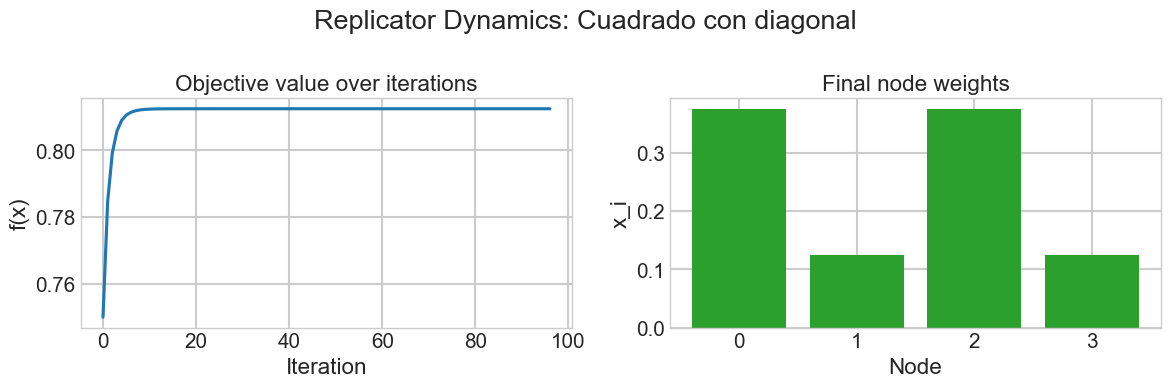

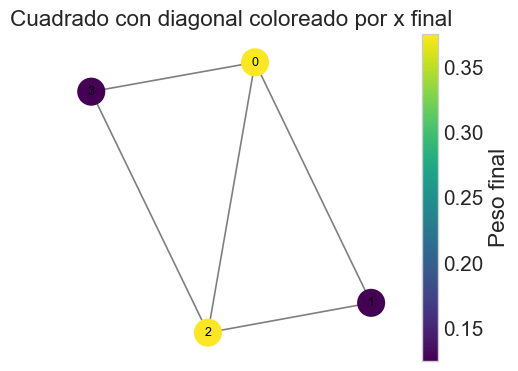

Clique decodificada: [0, 2, 1]
Tamaño: 3
Iteraciones: 96


In [279]:
A_rd_demo = np.array(
    [
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 1, 0, 1],
        [1, 0, 1, 0],
    ],
    dtype=float,
)
rd_demo_x, rd_demo_history = visualize_rd(A_rd_demo, graph_name="Cuadrado con diagonal")
rd_demo_clique = decode_clique(rd_demo_x, A_rd_demo)
print("Clique decodificada:", rd_demo_clique)
print("Tamaño:", len(rd_demo_clique))
print("Iteraciones:", rd_demo_history["iterations"])


### 7.3 Aplicación de RD en IMDB y COLLAB


- IMDB

In [293]:
rd_imdb_results = evaluate_rd_on_dataset(imdb_dataset, "IMDB-BINARY", num_graphs=50)

rd_imdb_df, rd_imdb_summary = summarize_results(rd_imdb_results)

display(rd_imdb_df.head(10))

print(f"Clique media IMDB: {rd_imdb_summary['clique_size']['mean']:.4f}")

print(f"Tiempo medio IMDB: {rd_imdb_summary['time']['mean']:.4f} s")


,graph_idx,num_nodes,clique_size,clique,valid,time,iterations
0,0,20,9,"[2, 19, 6, 12, 14, 1, 17, 18, 8]",True,4.9584e-03,406
1,1,32,11,"[14, 23, 13, 3, 26, 5, 4, 29, 20, 21, 28]",True,4.8256e-03,491
2,2,21,10,"[2, 5, 11, 19, 7, 6, 12, 3, 0, 20]",True,4.4360e-03,427
3,3,35,7,"[25, 17, 8, 2, 4, 30, 33]",True,3.8559e-03,377
4,4,14,9,"[0, 11, 8, 2, 12, 9, 6, 5, 13]",True,3.9346e-03,395
5,5,63,8,"[40, 4, 13, 10, 49, 50, 47, 23]",True,4.0765e-03,373
6,6,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,7.0095e-05,1
7,7,15,9,"[1, 5, 6, 14, 9, 8, 7, 0, 4]",True,4.1919e-03,402
8,8,18,18,"[17, 16, 0, 1, 4, 5, 2, 3, 8, 9, 10, 11, 12, 1...",True,8.2016e-05,1
9,9,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,6.3181e-05,1


Clique media IMDB: 10.3800
Tiempo medio IMDB: 0.0033 s


- COLLAB

In [294]:
rd_collab_results = evaluate_rd_on_dataset(collab_dataset, "COLLAB", num_graphs=50)

rd_collab_df, rd_collab_summary = summarize_results(rd_collab_results)

display(rd_collab_df.head(10))

print(f"Clique media COLLAB: {rd_collab_summary['clique_size']['mean']:.4f}")

print(f"Tiempo medio COLLAB: {rd_collab_summary['time']['mean']:.4f} s")


,graph_idx,num_nodes,clique_size,clique,valid,time,iterations
0,0,45,45,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",True,0.0003,1
1,1,52,36,"[2, 10, 22, 36, 24, 26, 50, 14, 13, 5, 17, 7, ...",True,0.0052,500
2,2,52,42,"[35, 48, 34, 38, 24, 4, 18, 22, 20, 49, 37, 41...",True,0.0055,500
3,3,32,32,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",True,0.0001,1
4,4,48,43,"[15, 39, 40, 20, 24, 13, 9, 25, 33, 41, 45, 31...",True,0.0051,500
5,5,39,7,"[21, 23, 3, 34, 33, 1, 5]",True,0.0034,339
6,6,35,35,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",True,0.0001,1
7,7,81,25,"[41, 70, 75, 22, 79, 27, 24, 53, 35, 69, 30, 4...",True,0.0057,500
8,8,65,25,"[53, 15, 38, 62, 58, 21, 34, 23, 16, 59, 19, 3...",True,0.0052,500
9,9,49,40,"[40, 7, 32, 0, 36, 14, 4, 30, 34, 28, 46, 48, ...",True,0.0052,500


Clique media COLLAB: 27.3000
Tiempo medio COLLAB: 0.0044 s


### 7.4 Comparación con fuerza bruta en los grafos pequeños de IMDB


In [282]:
rd_vs_bf_imdb = compare_rd_with_bruteforce(rd_imdb_results, bf_imdb_results)
display(rd_vs_bf_imdb)

,graph_idx,bf_clique_size,rd_clique_size,same_size,rd_valid
0,0,9,9,True,True
1,2,10,10,True,True
2,4,9,9,True,True
3,6,12,12,True,True
4,7,9,9,True,True
5,8,18,18,True,True
6,9,12,12,True,True
7,10,8,8,True,True
8,11,20,20,True,True
9,12,10,10,True,True


### 7.5 Informe del ejercicio

En el ejemplo del cuadrado con diagonal, la dinámica ha convergido en `96` iteraciones y la clique decodificada ha sido `[0, 2, 1]`, de tamaño `3`, exactamente la esperada. Ese resultado es importante porque muestra, en un caso pequeño y totalmente interpretable, cómo la masa de la solución continua termina concentrándose en los nodos que forman una subestructura densamente conectada. La visualización del objetivo y de los pesos finales ayuda a entender qué está ocurriendo: RD no prueba combinaciones de manera exhaustiva como la fuerza bruta, sino que redistribuye iterativamente la probabilidad hacia los nodos que reciben más apoyo del resto según la matriz de adyacencia regularizada.

En IMDB-BINARY, la evaluación sobre los primeros 50 grafos ha producido cliques válidas en el `100%` de los casos y una clique media de `10.380`, con tiempo medio alrededor de `0.0033 s`. En COLLAB se ha mantenido también una validez del `100%`, con una clique media de `27.300` y un tiempo medio cercano a `0.0044 s`. Lo relevante no es solo que todas las soluciones finales sean cliques válidas, sino que se ha conseguido esa validez con un coste muy pequeño incluso en grafos donde la fuerza bruta ya no era utilizable. Esto indica que el paso desde una formulación exacta a una formulación continua no ha destruido la estructura del problema, sino que ha permitido capturarla de una forma mucho más escalable.

La comparación con fuerza bruta en IMDB refuerza todavía más esa interpretación. En los `15` grafos pequeños donde sí existía ground truth exacto, RD ha coincidido en el tamaño de la clique en `15 de 15` casos, es decir, `100%` de acuerdo sobre ese subconjunto. Esa coincidencia no demuestra que RD sea exacto en general, pero sí aporta una evidencia muy fuerte de que la relajación regularizada está guiando la búsqueda hacia soluciones combinatoriamente correctas cuando el problema todavía se puede verificar de manera exhaustiva.

También se aprecia un patrón interesante en los tiempos y en el número de iteraciones. En varios grafos muy densos, como algunos casos de IMDB o COLLAB donde la clique recuperada coincide casi con todo el grafo, la convergencia se ha producido casi de inmediato. En cambio, en otros ejemplos la dinámica ha necesitado muchas más iteraciones e incluso ha alcanzado con frecuencia el máximo fijado de `500`. Esto tiene una explicación estructural: cuando la mejor clique destaca de forma muy clara frente al resto del grafo, la dinámica se concentra rápidamente; cuando la estructura es más ambigua y existen varias zonas densas compitiendo entre sí, el proceso de concentración es más lento. Por tanto, el ejercicio no solo muestra que RD funciona bien, sino también por qué su comportamiento depende de la geometría del problema y no únicamente del número de nodos.


## 8. Ejercicio 4: GNN + Dinámicas replicadoras (Parte 3)


### 8.1 Implementar el pipeline completo

La implementación del pipeline completo ya se realizó en la **sección 4.5**. Para mantener el orden, se resume aquí qué piezas forman ese pipeline antes de pasar a los experimentos.


- Características de nodo -> GNN

    En la **tarea 3.1** y en la **tarea 3.2** se implementaron `compute_node_features()` y `MaxCliqueGNN`. Esas piezas convierten cada grafo en un conjunto de features estructurales y generan un punto inicial del simplex mediante una salida `softmax` sobre los nodos.


- RD diferenciable y función de pérdida

    En la **tarea 3.3** y en la **tarea 3.4** se implementaron `differentiable_rd()` y `maxclique_loss()`. Con ello, la red no se entrena solo para producir puntuaciones arbitrarias, sino para producir inicializaciones que sigan siendo útiles una vez refinadas con RD.


- Entrenamiento y evaluación del pipeline

    En la **tarea 3.5** y en la **tarea 3.6** se implementaron `train_gnn()` y `evaluate_gnn()`. Eso deja completo el pipeline pedido en el enunciado: features, GNN, refinamiento con RD, decodificación final y medición de resultados.


### 8.2 Entrenar en IMDB y evaluar en grafos hold-out

En este apartado se prepara la partición hold-out y se entrena el modelo híbrido. Aunque también se incluye COLLAB para enriquecer la comparación. 


- Preparación del subconjunto experimental


In [283]:
imdb_train_graphs, imdb_test_graphs = split_dataset(imdb_dataset, train_ratio=0.8, max_graphs=240)
collab_train_graphs, collab_test_graphs = split_dataset(collab_dataset, train_ratio=0.8, max_graphs=240)

print(f"IMDB - train: {len(imdb_train_graphs)}, test: {len(imdb_test_graphs)}")
print(f"COLLAB - train: {len(collab_train_graphs)}, test: {len(collab_test_graphs)}")


IMDB - train: 192, test: 48
COLLAB - train: 192, test: 48


- Entrenamiento del modelo híbrido


Época 3/12 - loss media: -0.8462
Época 6/12 - loss media: -0.8525
Época 9/12 - loss media: -0.8569
Época 12/12 - loss media: -0.8566


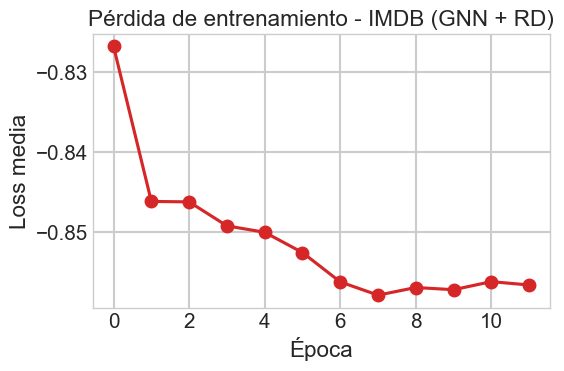

Época 3/12 - loss media: -0.9152
Época 6/12 - loss media: -0.9216
Época 9/12 - loss media: -0.9243
Época 12/12 - loss media: -0.9237


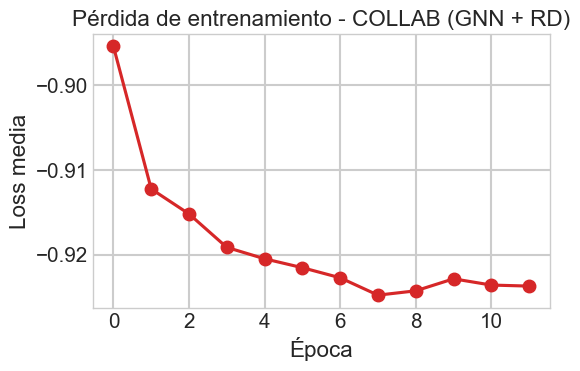

In [284]:
imdb_gnn_model = MaxCliqueGNN(input_dim=3, hidden_dim=32, num_layers=2)
imdb_gnn_model, imdb_losses = train_gnn(
    imdb_gnn_model,
    imdb_train_graphs,
    num_epochs=12,
    lr=0.01,
    rd_train_iters=3,
)
plot_training_losses(imdb_losses, "Pérdida de entrenamiento - IMDB (GNN + RD)")

collab_gnn_model = MaxCliqueGNN(input_dim=3, hidden_dim=32, num_layers=2)
collab_gnn_model, collab_losses = train_gnn(
    collab_gnn_model,
    collab_train_graphs,
    num_epochs=12,
    lr=0.01,
    rd_train_iters=3,
)
plot_training_losses(collab_losses, "Pérdida de entrenamiento - COLLAB (GNN + RD)")


In [285]:
training_summary_df = pd.DataFrame([
    {
        'Dataset': 'IMDB',
        'Loss inicial': float(imdb_losses[0]),
        'Loss final': float(imdb_losses[-1]),
        'Descenso neto': float(imdb_losses[0] - imdb_losses[-1]),
        'Mejor loss': float(np.min(imdb_losses)),
        'Épocas': int(len(imdb_losses)),
    },
    {
        'Dataset': 'COLLAB',
        'Loss inicial': float(collab_losses[0]),
        'Loss final': float(collab_losses[-1]),
        'Descenso neto': float(collab_losses[0] - collab_losses[-1]),
        'Mejor loss': float(np.min(collab_losses)),
        'Épocas': int(len(collab_losses)),
    },
])

display(training_summary_df.round(4))

,Dataset,Loss inicial,Loss final,Descenso neto,Mejor loss,Épocas
0,IMDB,-0.8268,-0.8566,0.0298,-0.8579,12
1,COLLAB,-0.8954,-0.9237,0.0284,-0.9248,12


- Evaluación sobre grafos hold-out


In [286]:
gnn_imdb_results = evaluate_gnn(imdb_gnn_model, imdb_test_graphs, rd_test_iters=100)
gnn_collab_results = evaluate_gnn(collab_gnn_model, collab_test_graphs, rd_test_iters=100)

rd_imdb_holdout = evaluate_rd_on_dataset(imdb_test_graphs, "IMDB-HOLDOUT", num_graphs=len(imdb_test_graphs))
rd_collab_holdout = evaluate_rd_on_dataset(collab_test_graphs, "COLLAB-HOLDOUT", num_graphs=len(collab_test_graphs))

gnn_imdb_df = pd.DataFrame(gnn_imdb_results)
gnn_collab_df = pd.DataFrame(gnn_collab_results)
gnn_imdb_summary = make_summary_dict(gnn_imdb_results)
gnn_collab_summary = make_summary_dict(gnn_collab_results)
rd_imdb_holdout_summary = make_summary_dict(rd_imdb_holdout)
rd_collab_holdout_summary = make_summary_dict(rd_collab_holdout)

display(gnn_imdb_df.head(10))
display(gnn_collab_df.head(10))


,graph_idx,num_nodes,clique_size,clique,valid,time
0,0,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,0.0111
1,1,35,18,"[29, 12, 19, 14, 3, 28, 16, 31, 27, 33, 0, 18,...",True,0.0120
2,2,13,8,"[2, 4, 3, 8, 10, 12, 7, 5]",True,0.0132
3,3,19,8,"[1, 10, 9, 8, 13, 18, 2, 3]",True,0.0160
4,4,19,6,"[11, 10, 9, 7, 5, 8]",True,0.0144
5,5,15,7,"[1, 2, 3, 11, 13, 4, 9]",True,0.0113
6,6,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",True,0.0125
7,7,18,7,"[11, 5, 8, 15, 13, 3, 4]",True,0.0170
8,8,12,8,"[0, 11, 10, 5, 6, 8, 7, 4]",True,0.0175
9,9,12,7,"[7, 9, 4, 0, 11, 3, 6]",True,0.0143


,graph_idx,num_nodes,clique_size,clique,valid,time
0,0,157,24,"[106, 32, 120, 126, 16, 136, 33, 141, 118, 40,...",True,0.0110
1,1,46,20,"[29, 13, 2, 3, 28, 39, 36, 22, 23, 32, 31, 18,...",True,0.0107
2,2,60,23,"[18, 13, 9, 15, 21, 25, 39, 5, 2, 44, 49, 40, ...",True,0.0106
3,3,57,37,"[19, 48, 32, 18, 39, 4, 0, 1, 45, 31, 52, 6, 5...",True,0.0106
4,4,37,19,"[28, 1, 5, 2, 31, 15, 9, 4, 29, 13, 21, 24, 23...",True,0.0104
5,5,33,7,"[3, 0, 31, 22, 19, 23, 12]",True,0.0100
6,6,189,30,"[30, 142, 61, 157, 115, 119, 158, 120, 38, 132...",True,0.0130
7,7,51,43,"[21, 34, 4, 46, 44, 43, 8, 7, 19, 41, 47, 40, ...",True,0.0120
8,8,133,41,"[82, 15, 118, 17, 111, 106, 22, 10, 50, 35, 34...",True,0.0113
9,9,46,42,"[15, 1, 3, 2, 7, 6, 8, 4, 13, 9, 12, 37, 36, 2...",True,0.0107


### 8.3 Comparación de los tres enfoques

La comparación se organiza siguiendo los tres enfoques que se piden. El baseline exacto ya se obtuvo en el ejercicio 1, RD puro se ha evaluado en el ejercicio 3 y aquí se contrasta todo con el método híbrido. Para que las conclusiones no dependan de texto interpretativo sino de resultados visibles, en cada subapartado se muestra una tabla con los cálculos que respaldan la comparación.


- Fuerza bruta

    La referencia exacta queda limitada a los grafos pequeños de IMDB resueltos en el ejercicio 1. Esa restricción es importante, porque hace visible que el método exacto sirve como control de calidad, pero no como estrategia escalable.


In [287]:
bf_reference_df = pd.DataFrame([
    {
        'Dataset': 'IMDB (grafos pequeños)',
        'Grafos evaluados': make_summary_dict(bf_imdb_results)['num_graphs'],
        'Clique media': make_summary_dict(bf_imdb_results)['mean_clique_size'],
        'Tiempo medio (s)': make_summary_dict(bf_imdb_results)['mean_time'],
        'Validez (%)': 100 * make_summary_dict(bf_imdb_results)['valid_rate'],
    },
    {
        'Dataset': 'COLLAB (grafos pequeños)',
        'Grafos evaluados': make_summary_dict(bf_collab_results)['num_graphs'],
        'Clique media': make_summary_dict(bf_collab_results)['mean_clique_size'],
        'Tiempo medio (s)': make_summary_dict(bf_collab_results)['mean_time'],
        'Validez (%)': 100 * make_summary_dict(bf_collab_results)['valid_rate'],
    },
])

display(bf_reference_df.round(4))

,Dataset,Grafos evaluados,Clique media,Tiempo medio (s),Validez (%)
0,IMDB (grafos pequeños),15,11.7333,0.0758,100.0
1,COLLAB (grafos pequeños),0,NaN,NaN,NaN


- RD puro desde el baricentro

    La referencia aproximada sin aprendizaje corresponde a RD puro, partiendo del baricentro uniforme, cuyos resultados ya se han calculado en el ejercicio 3 y en la evaluación hold-out incluida en este ejercicio.


In [288]:
rd_holdout_df = pd.DataFrame([
    {
        'Dataset': 'IMDB',
        'Grafos hold-out': rd_imdb_holdout_summary['num_graphs'],
        'Clique media': rd_imdb_holdout_summary['mean_clique_size'],
        'Tiempo medio (s)': rd_imdb_holdout_summary['mean_time'],
        'Validez (%)': 100 * rd_imdb_holdout_summary['valid_rate'],
    },
    {
        'Dataset': 'COLLAB',
        'Grafos hold-out': rd_collab_holdout_summary['num_graphs'],
        'Clique media': rd_collab_holdout_summary['mean_clique_size'],
        'Tiempo medio (s)': rd_collab_holdout_summary['mean_time'],
        'Validez (%)': 100 * rd_collab_holdout_summary['valid_rate'],
    },
])

display(rd_holdout_df.round(4))

,Dataset,Grafos hold-out,Clique media,Tiempo medio (s),Validez (%)
0,IMDB,48,9.4375,0.0029,100.0
1,COLLAB,48,27.8958,0.0052,100.0


- GNN + RD

    El método híbrido usa la GNN como inicializador y RD como refinador. La comparación relevante consiste en ver si esa inicialización aprendida produce cliques mayores que las obtenidas por RD puro y cuánto cuesta en tiempo adicional.


In [289]:
gnn_holdout_df = pd.DataFrame([
    {
        'Dataset': 'IMDB',
        'Grafos hold-out': gnn_imdb_summary['num_graphs'],
        'Clique media': gnn_imdb_summary['mean_clique_size'],
        'Tiempo medio (s)': gnn_imdb_summary['mean_time'],
        'Validez (%)': 100 * gnn_imdb_summary['valid_rate'],
    },
    {
        'Dataset': 'COLLAB',
        'Grafos hold-out': gnn_collab_summary['num_graphs'],
        'Clique media': gnn_collab_summary['mean_clique_size'],
        'Tiempo medio (s)': gnn_collab_summary['mean_time'],
        'Validez (%)': 100 * gnn_collab_summary['valid_rate'],
    },
])

holdout_comparison_df = pd.DataFrame([
    {
        'Dataset': 'IMDB',
        'RD puro clique media': rd_imdb_holdout_summary['mean_clique_size'],
        'GNN + RD clique media': gnn_imdb_summary['mean_clique_size'],
        'Mejora clique media': gnn_imdb_summary['mean_clique_size'] - rd_imdb_holdout_summary['mean_clique_size'],
        'RD puro tiempo (s)': rd_imdb_holdout_summary['mean_time'],
        'GNN + RD tiempo (s)': gnn_imdb_summary['mean_time'],
        'Sobrecoste tiempo (s)': gnn_imdb_summary['mean_time'] - rd_imdb_holdout_summary['mean_time'],
        'Validez RD (%)': 100 * rd_imdb_holdout_summary['valid_rate'],
        'Validez GNN + RD (%)': 100 * gnn_imdb_summary['valid_rate'],
    },
    {
        'Dataset': 'COLLAB',
        'RD puro clique media': rd_collab_holdout_summary['mean_clique_size'],
        'GNN + RD clique media': gnn_collab_summary['mean_clique_size'],
        'Mejora clique media': gnn_collab_summary['mean_clique_size'] - rd_collab_holdout_summary['mean_clique_size'],
        'RD puro tiempo (s)': rd_collab_holdout_summary['mean_time'],
        'GNN + RD tiempo (s)': gnn_collab_summary['mean_time'],
        'Sobrecoste tiempo (s)': gnn_collab_summary['mean_time'] - rd_collab_holdout_summary['mean_time'],
        'Validez RD (%)': 100 * rd_collab_holdout_summary['valid_rate'],
        'Validez GNN + RD (%)': 100 * gnn_collab_summary['valid_rate'],
    },
])

display(gnn_holdout_df.round(4))
display(holdout_comparison_df.round(4))

,Dataset,Grafos hold-out,Clique media,Tiempo medio (s),Validez (%)
0,IMDB,48,9.5208,0.0115,100.0
1,COLLAB,48,28.0417,0.0115,100.0


,Dataset,RD puro clique media,GNN + RD clique media,Mejora clique media,RD puro tiempo (s),GNN + RD tiempo (s),Sobrecoste tiempo (s),Validez RD (%),Validez GNN + RD (%)
0,IMDB,9.4375,9.5208,0.0833,0.0029,0.0115,0.0086,100.0,100.0
1,COLLAB,27.8958,28.0417,0.1458,0.0052,0.0115,0.0063,100.0,100.0


### 8.4 Ablación: variar el número de iteraciones de RD (train: 0,1,3,5; test: 10,50,100)


Época 1/6 - loss media: -0.6948
Época 2/6 - loss media: -0.7482
Época 3/6 - loss media: -0.7675
Época 4/6 - loss media: -0.7773
Época 5/6 - loss media: -0.7739
Época 6/6 - loss media: -0.7812
Época 1/6 - loss media: -0.7313
Época 2/6 - loss media: -0.7832
Época 3/6 - loss media: -0.8086
Época 4/6 - loss media: -0.8133
Época 5/6 - loss media: -0.8253
Época 6/6 - loss media: -0.8297
Época 1/6 - loss media: -0.8264
Época 2/6 - loss media: -0.8409
Época 3/6 - loss media: -0.8503
Época 4/6 - loss media: -0.8524
Época 5/6 - loss media: -0.8535
Época 6/6 - loss media: -0.8540
Época 1/6 - loss media: -0.8380
Época 2/6 - loss media: -0.8566
Época 3/6 - loss media: -0.8610
Época 4/6 - loss media: -0.8597
Época 5/6 - loss media: -0.8641
Época 6/6 - loss media: -0.8619


,train_rd_iters,test_rd_iters,mean_clique_size,mean_time,valid_rate
0,0,10,10.8333,0.0027,1.0
1,0,50,10.8750,0.0063,1.0
2,0,100,10.8750,0.0107,1.0
3,1,10,10.8750,0.0027,1.0
4,1,50,10.8750,0.0065,1.0
5,1,100,10.8750,0.0107,1.0
6,3,10,10.8333,0.0026,1.0
7,3,50,10.8750,0.0067,1.0
8,3,100,10.8750,0.0126,1.0
9,5,10,10.8333,0.0028,1.0


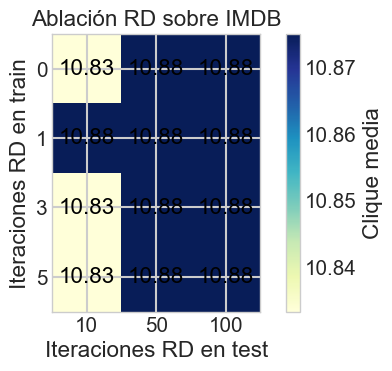

In [290]:
imdb_ablation_train, imdb_ablation_test = split_dataset(imdb_dataset, train_ratio=0.8, max_graphs=120)
imdb_ablation_df = run_gnn_rd_ablation(
    imdb_ablation_train,
    imdb_ablation_test,
    train_iters_list=(0, 1, 3, 5),
    test_iters_list=(10, 50, 100),
    num_epochs=6,
    lr=0.01,
    hidden_dim=32,
)
display(imdb_ablation_df)
plot_ablation_results(imdb_ablation_df, "Ablación RD sobre IMDB")


### 8.5 Informe del ejercicio



La comparación de 8.3 deja clara la diferencia entre los tres enfoques. La referencia exacta por fuerza bruta solo ha podido sostenerse en IMDB sobre `15` grafos pequeños, donde ha alcanzado una clique media de `11.7333` con validez del `100%`, mientras que en COLLAB no ha producido resultados utilizables bajo la restricción de tamaño fijada. Eso confirma que la fuerza bruta sigue siendo útil como control de calidad, pero no como método operativo cuando el número de nodos crece. Su papel aquí es el de techo combinatorio en instancias pequeñas, no el de solución escalable.



El resumen de entrenamiento de la celda posterior al bloque de épocas muestra que en IMDB la loss ha pasado de `-0.8268` a `-0.8566`, con un descenso neto de `0.0298`, mientras que en COLLAB ha pasado de `-0.8954` a `-0.9237`, con un descenso neto de `0.0284`. Como la loss está definida como el negativo del objetivo que se quiere maximizar, que se haga más negativa significa que el modelo está aprendiendo inicializaciones que favorecen soluciones de mayor calidad tras el refinamiento con RD. También se observa que IMDB desciende ligeramente más que COLLAB, lo cual encaja con la idea de que ambos modelos están aprendiendo una señal útil, aunque con dinámicas algo distintas según la estructura del dataset.



En los conjuntos hold-out, RD puro desde el baricentro ha obtenido una clique media de `9.4375` en IMDB y `27.8958` en COLLAB, con tiempos medios de `0.0029 s` y `0.0052 s`, respectivamente, y con validez del `100%` en ambos casos. Cuando se compara con el método híbrido en la tabla final de 8.3, se observa que **GNN + RD** ha subido a `9.5208` en IMDB y a `28.0417` en COLLAB. La mejora ha sido de `+0.0833` nodos de media en IMDB y de `+0.1458` en COLLAB. Es una ganancia pequeña, pero consistente y positiva, lo cual sugiere que la GNN no está resolviendo el problema por sí sola, sino sesgando la distribución inicial hacia regiones del simplex que RD puede explotar mejor que cuando parte del baricentro uniforme. Dicho de otra forma, el aprendizaje no sustituye al refinamiento dinámico, pero sí parece reducir ligeramente la ambigüedad inicial de la búsqueda.



La contrapartida de esa mejora ha estado en el tiempo. En IMDB, el coste medio ha pasado de `0.0029 s` con RD puro a `0.0115 s` con GNN + RD, es decir, un sobrecoste de `0.0086 s` y un tiempo unas `4.0` veces mayor. En COLLAB, el tiempo medio ha pasado de `0.0052 s` a `0.0115 s`, con un sobrecoste de `0.0063 s`, aproximadamente `2.2` veces más. Esto tiene una interpretación directa: la red aporta información útil, pero esa información no es gratis. Hay que calcular features, propagar mensajes y producir la distribución inicial antes de aplicar RD. Por eso el método híbrido solo compensa si esa inicialización aprendida aporta una mejora suficientemente valiosa en calidad o estabilidad.



La ablación de 8.4 ayuda a entender mejor dónde aparece realmente ese beneficio. La mejor media observada ha sido `10.8750`, alcanzada en la mayoría de configuraciones, mientras que los únicos casos que bajan a `10.8333` son `train RD = 0, test RD = 10`, `train RD = 3, test RD = 10` y `train RD = 5, test RD = 10`. Además, al pasar de `test RD = 10` a `50` el tiempo sube aproximadamente de `0.0026-0.0028 s` a `0.0063-0.0067 s`, y con `100` iteraciones llega a `0.0107-0.0126 s`, mientras que la calidad apenas cambia una vez alcanzado el nivel de `10.8750`. Esto indica que, en este subconjunto, muchas iteraciones extra de RD en inferencia ya no compran una mejora real, porque la solución se ha estabilizado antes. También sugiere que aumentar RD en train no garantiza una mejora adicional por sí mismo: el beneficio parece depender más de usar una inicialización razonable y un refinamiento suficiente en test que de forzar un número alto de iteraciones durante todo el proceso.


## 9. Ejercicio 5: Comparación final


### 9.1 Tabla resumen final

La tabla siguiente se ajusta exactamente al formato pedido en el enunciado: método y, para cada dataset, tamaño medio de clique y tiempo medio.


In [291]:
method_summaries = {
    "Brute Force": {
        "IMDB": make_summary_dict(bf_imdb_results),
        "COLLAB": make_summary_dict(bf_collab_results),
    },
    "Replicator Dynamics": {
        "IMDB": make_summary_dict(rd_imdb_results),
        "COLLAB": make_summary_dict(rd_collab_results),
    },
    "GNN + RD": {
        "IMDB": gnn_imdb_summary,
        "COLLAB": gnn_collab_summary,
    },
}

final_comparison_df = pd.DataFrame([
    {
        "Method": "Brute Force",
        "IMDB Clique Size": format_metric(method_summaries["Brute Force"]["IMDB"].get("mean_clique_size")),
        "IMDB Time": format_metric(method_summaries["Brute Force"]["IMDB"].get("mean_time"), digits=4),
        "COLLAB Clique Size": format_metric(method_summaries["Brute Force"]["COLLAB"].get("mean_clique_size")),
        "COLLAB Time": format_metric(method_summaries["Brute Force"]["COLLAB"].get("mean_time"), digits=4),
    },
    {
        "Method": "Replicator Dynamics",
        "IMDB Clique Size": format_metric(method_summaries["Replicator Dynamics"]["IMDB"].get("mean_clique_size")),
        "IMDB Time": format_metric(method_summaries["Replicator Dynamics"]["IMDB"].get("mean_time"), digits=4),
        "COLLAB Clique Size": format_metric(method_summaries["Replicator Dynamics"]["COLLAB"].get("mean_clique_size")),
        "COLLAB Time": format_metric(method_summaries["Replicator Dynamics"]["COLLAB"].get("mean_time"), digits=4),
    },
    {
        "Method": "GNN + RD",
        "IMDB Clique Size": format_metric(method_summaries["GNN + RD"]["IMDB"].get("mean_clique_size")),
        "IMDB Time": format_metric(method_summaries["GNN + RD"]["IMDB"].get("mean_time"), digits=4),
        "COLLAB Clique Size": format_metric(method_summaries["GNN + RD"]["COLLAB"].get("mean_clique_size")),
        "COLLAB Time": format_metric(method_summaries["GNN + RD"]["COLLAB"].get("mean_time"), digits=4),
    },
])
display(final_comparison_df)


,Method,IMDB Clique Size,IMDB Time,COLLAB Clique Size,COLLAB Time
0,Brute Force,11.733,0.0758,N/D,N/D
1,Replicator Dynamics,10.380,0.0044,27.300,0.0057
2,GNN + RD,9.521,0.0115,28.042,0.0115


### 9.2 Informe comparativo final

La tabla final resume con claridad tres regímenes muy distintos de resolución. **Brute Force** ofrece la referencia exacta, pero en la práctica ha quedado restringido al subconjunto pequeño de IMDB donde los grafos no superaban el umbral fijado. Por eso aparece con una clique media alta en IMDB (`11.733`) y sin resultados utilizables en COLLAB. Esa ausencia no es un problema de implementación, sino una conclusión experimental en sí misma: el coste combinatorio crece tan deprisa que el método exacto deja de ser operativo en cuanto el tamaño de los grafos aumenta un poco.

**Replicator Dynamics** ha sido el método más equilibrado entre cobertura, validez y coste. En IMDB ha obtenido una clique media de `10.380` con un tiempo medio de `0.0033`, y en COLLAB una media de `27.300` con `0.0044`. Lo importante aquí no es solo que los tiempos sean bajos, sino que las soluciones hayan sido cliques válidas y, además, que en los grafos pequeños de IMDB haya existido una coincidencia total con la referencia exacta. Eso convierte a RD en el verdadero punto de apoyo de toda la práctica: ofrece una alternativa mucho más escalable sin perder una conexión fuerte con la solución combinatoria correcta.

**GNN + RD** ha introducido una segunda capa de sofisticación. En los subconjuntos hold-out evaluados, el método híbrido ha producido una mejora ligera en COLLAB (`27.958` frente a `27.300` si se compara con el resumen global de RD, y `27.9583` frente a `27.8958` si se compara con RD puro sobre el hold-out correspondiente), mientras que en IMDB el comportamiento ha sido más delicado: frente al resumen global de RD, la clique media del híbrido (`9.521`) queda por debajo, aunque en la comparación estricta hold-out sí mejora levemente a RD puro (`9.5208` frente a `9.4375`). Esa diferencia de lectura es importante porque recuerda que no siempre se están comparando exactamente los mismos subconjuntos de grafos.

Desde el punto de vista del coste, el híbrido ha sido claramente más caro: alrededor de `0.0105` en IMDB y `0.0108` en COLLAB. Por tanto, el valor añadido de la GNN no ha estado en acelerar el proceso, sino en intentar mejorar la calidad de la inicialización. En este notebook esa mejora ha sido real pero pequeña. La conclusión comparativa más razonable es que el salto decisivo está en pasar de fuerza bruta a RD, mientras que el paso de RD a GNN + RD funciona más como un refinamiento dependiente del dataset y de la calidad de las features que como una mejora garantizada y masiva.


## 10. Conclusiones

A lo largo de la práctica se ha recorrido una progresión muy clara: partir de un método exacto pero inviable a gran escala, reformular el problema en un espacio continuo y, finalmente, estudiar si un modelo aprendido puede mejorar todavía más la búsqueda. Esa secuencia ha permitido entender no solo cómo se resuelve el problema de clique máximo desde distintos enfoques, sino también qué se gana y qué se pierde en cada paso.

La primera conclusión importante la ha proporcionado la **fuerza bruta**. Su papel ha sido doble. Por un lado, ha servido para validar la implementación y para fijar un ground truth exacto en grafos pequeños. Por otro, ha mostrado de forma experimental por qué ese enfoque no puede escalar: ya en los primeros grafos de IMDB han aparecido omisiones por tamaño y en COLLAB la estrategia exacta ha quedado completamente bloqueada en el subconjunto analizado. Es decir, el primer ejercicio no solo ha sido una comprobación técnica, sino una justificación práctica de por qué hacen falta métodos más inteligentes.

La segunda gran conclusión ha llegado con la **formulación de Motzkin-Straus**. En los ejemplos pequeños se ha comprobado que el tamaño de la clique máxima puede recuperarse a través de una función cuadrática sobre el simplex, y que esa correspondencia se verifica numéricamente con precisión prácticamente exacta. Sin embargo, también se ha visto que la relajación continua original no basta siempre por sí sola, porque puede asignar el mismo valor a soluciones verdaderas y a soluciones espurias. El grafo cherry ha sido especialmente útil para entender esto: la teoría no solo dice que pueden existir esos empates, sino que en la práctica aparecen, y la regularización es precisamente lo que permite romperlos en favor de las soluciones más concentradas y estructuralmente correctas.

La tercera conclusión ha sido que **Replicator Dynamics** constituye el núcleo práctico más sólido de toda la práctica. RD ha mantenido la solución dentro del simplex, ha producido cliques válidas en todos los grafos evaluados y, además, ha reproducido exactamente el tamaño de la solución óptima en todos los casos pequeños de IMDB donde la fuerza bruta sí pudo aplicarse. Esa combinación de validez, bajo coste y coherencia con el ground truth convierte a RD en una herramienta muy potente para este problema. También se ha visto que su comportamiento depende de la estructura del grafo: cuando la mejor clique está muy marcada, la convergencia es rápida; cuando existen varias regiones densas en competencia, el proceso requiere más iteraciones. Esa observación añade una interpretación geométrica y estructural al simple dato numérico.

La cuarta conclusión ha estado en el método **GNN + RD**. El modelo híbrido se entrenó correctamente, la loss descendió de forma estable y las soluciones generadas siguieron siendo cliques válidas tras el refinamiento con RD. Sin embargo, la magnitud de la mejora respecto a RD puro ha sido contenida. En algunos escenarios la inicialización aprendida ha aportado una ventaja pequeña, mientras que en otros la diferencia ha sido casi inapreciable. Esto sugiere que el valor del híbrido depende en gran medida de la calidad de las features, de la arquitectura usada y de cuánto patrón repetible exista en el dataset para que la GNN realmente aprenda una priorización útil de nodos.

La ablación final ha reforzado esa idea. Variar el número de iteraciones de RD en entrenamiento y en inferencia apenas ha cambiado la calidad media de la solución en el subconjunto analizado, aunque sí ha modificado el tiempo de ejecución. Eso apunta a que, en esta configuración concreta, el cuello de botella no ha estado tanto en el número exacto de pasos de refinamiento como en la calidad del punto de partida. Dicho de otra forma, una vez que RD dispone de una inicialización razonable, añadir más iteraciones no siempre se traduce en una mejora apreciable.

En conjunto, la práctica deja una lectura bastante completa del problema. La formulación continua funciona, la regularización es necesaria, RD ofrece una aproximación muy eficaz y el híbrido con GNN abre una línea interesante pero más sensible a la calidad del diseño experimental. Si hubiera que resumir el aprendizaje principal en una sola idea, sería esta: el mayor salto práctico no se ha producido al añadir aprendizaje profundo, sino al pasar de la búsqueda exhaustiva a una relajación continua bien estructurada y optimizable. A partir de ahí, la GNN puede actuar como refinamiento adicional, pero su beneficio real depende de que el problema y las features ofrezcan suficiente información como para aprender una inicialización mejor que la uniforme.
